# CARBAMYLATION ANALYSIS TOOL

This Jupyter notebook enables selecting and curating protein atomic structures for the analysis of their lysines. The aim, is to identify the subset of lysines that may be carbamylated. The pipeline is divided in the following steps.

* 1. [Data Gathering](#gather)
  - 1.1. [Mine UNIPROT database](#uniprot)
  - 1.2. [Mine PDB and AlphaFold databases](#pdb)
* 2. [Feature Extraction](#measure)
* 3. [Data Analysis](#analysis)
* 4. [Interactive Plots](#plot)

Further explanations about each of these steps are provided in the individual sections below.
Now, let's execute the cell below (press Shift+ENTER keys) to import all the Python packages required.

In [1]:
import os

#data handling
import numpy as np
import pandas as pd
pd.set_option("display.max_rows", None, "display.max_columns", None)

#plotting
import plotly.express as px
import plotly.graph_objects as go
import nglview as nv
from ipywidgets import HBox, VBox
from ipywidgets import widgets

# atomic structures manipulation
import biobox as bb

#carbamylation analysis procedures
from uniprot import Uniprot
from protein import PDB
from measure import Measure
from analysis import Analysis
from COOLPLOTS import CoolPlots

Before getting started, let's define an output directory. If none defined, the default name will be "result".

In [2]:
outdir="Demo"

## 1. Data Gathering  <a class="anchor" id="gather"></a>

### 1.1. Mine UNIPROT database  <a class="anchor" id="uniprot"></a>

Load data from UNIPROT database. The commands i.e. `from_csv_file` & `get_protein_data` can be launched multiple times, to compile a database saved in a pandas DataFrame (`Uniprot.df`).

For the demo, we only use two uniprot codes from the main dataset

In [3]:
# lets see the data first
df = pd.read_csv('cyano_reviewed_first10.csv')
df['Uniprot Entry']

0    P74285
1    Q8DIV4
2    P00879
3    P73832
4    Q55650
5    P77961
6    P73911
7    Q79PF6
8    Q55804
9    Q8DKB5
Name: Uniprot Entry, dtype: object

In [4]:
# load the csv file and search for structures for each uniprot code from Uniprot databse
UP = Uniprot()
UP.from_csv_file('cyano_reviewed_first10.csv')
UP.df

.csv file successfully opened


,Uniprot Entry,PDB Code,Method,Resolution,Chains
0,P74285,AF-P74285-F1-model_v1,Predicted,NaN,NaN
1,Q8DIV4,AF-Q8DIV4-F1-model_v1,Predicted,NaN,NaN
2,Q8DIV4,5OJR,X-ray,1.96,E/F
3,P00879,AF-P00879-F1-model_v1,Predicted,NaN,NaN
4,P00879,6KKM,X-ray,3.00,A/B/C/D
5,P00879,6LRR,EM,3.37,A/B/C/D/E/F/G/H
6,P00879,6LRS,EM,3.37,A/B/C/D/E/F/G/H
7,P00879,6Z1F,EM,2.86,A/B/C/D/E/F/G/H
8,P00879,6Z1G,EM,8.20,B/C
9,P73832,AF-P73832-F1-model_v1,Predicted,NaN,NaN


In [5]:
# alternatively we can process one uniprot code at a time
UP.get_protein_data('Q03513')
UP.df # note the old dataframe is extended

,Uniprot Entry,PDB Code,Method,Resolution,Chains
0,P74285,AF-P74285-F1-model_v1,Predicted,NaN,NaN
1,Q8DIV4,AF-Q8DIV4-F1-model_v1,Predicted,NaN,NaN
2,Q8DIV4,5OJR,X-ray,1.96,E/F
3,P00879,AF-P00879-F1-model_v1,Predicted,NaN,NaN
4,P00879,6KKM,X-ray,3.00,A/B/C/D
5,P00879,6LRR,EM,3.37,A/B/C/D/E/F/G/H
6,P00879,6LRS,EM,3.37,A/B/C/D/E/F/G/H
7,P00879,6Z1F,EM,2.86,A/B/C/D/E/F/G/H
8,P00879,6Z1G,EM,8.20,B/C
9,P73832,AF-P73832-F1-model_v1,Predicted,NaN,NaN


### 1.2. Mine PDB and AlphaFold databases  <a class="anchor" id="pdb"></a>

Load and curate all proteins described in a Uniprot DataFrame (`Uniprot.df`). Two optional parameters can be passed to the PDB constructor, `outdir` (output directory, "result" by default) and the largest acceptable gap in sequence (`gap`, 10 by default).

For each entry in the database:
* raw files are downloaded from the PDB in a subfolder within the output directory (defined by `PDB.raw_dir`, "conformations" by default)
* each raw file is cleaned: heteroatoms, hydrogens and non-protein, non-standard aminoacids are amended. Ions are preserved, as they may have important effect on the feature extraction phase
* different conformations (usually from NMR ensembles) are saved in different files
* if multiple aminoacid rotamers exist, multiple files are produced
* all produced files are patched, i.e. missing parts in the sequence are added using Modeller
* all files correctly patched are saved in a different subfolder in the output directory (defined by `PDB.curated_dir`, "curated" by default).

This process will generate a new DataFrame, `PDB.df`, containing information on all the structures that have been correctly curated.

<div class="alert alert-warning">
<b>Warning:</b> depending on how many proteins have to be downloaded and curated, this operation may take a long time. AlphaFold and PDB files not needing curation are processed in few seconds. Large multimers requiring curation can take up to 1 min. Multiple conformations in a single protein structure are individually curated.
</div>

In [6]:
pdb = PDB(outdir = outdir, gap = 10)
pdb.gather_proteins(UP.df) # this may take a few hours depending on the number of structures wanted


UNIPROT: P74285, PDB: AF-P74285-F1-model_v1
> downloading AlphaFold structure AF-P74285-F1-model_v1
>> FAILED: structure not found in AlphaFold database

UNIPROT: Q8DIV4, PDB: AF-Q8DIV4-F1-model_v1
> downloading AlphaFold structure AF-Q8DIV4-F1-model_v1
>> FAILED: structure not found in AlphaFold database

UNIPROT: Q8DIV4, PDB: 5OJR
> downloading PDB 5OJR
> downloading FASTA for 5OJR
>> Patching failed for conformer 0. large gap detected (334 residues)
>> FAILED: Patching failed for all conformers

UNIPROT: P00879, PDB: AF-P00879-F1-model_v1
> downloading AlphaFold structure AF-P00879-F1-model_v1
>> FAILED: structure not found in AlphaFold database

UNIPROT: P00879, PDB: 6KKM
> downloading PDB 6KKM
> downloading FASTA for 6KKM
>> Patching failed for conformer 0. large gap detected (22 residues)
>> FAILED: Patching failed for all conformers

UNIPROT: P00879, PDB: 6LRR
> downloading PDB 6LRR
> downloading FASTA for 6LRR
>> Patching failed for conformer 0. large gap detected (205 residue


Dynamically allocated memory at  amaxrestraints [B,KiB,MiB]:      2131608    2081.648     2.033

Dynamically allocated memory at  amaxrestraints [B,KiB,MiB]:      2262680    2209.648     2.158
r_stere_606_> Stereochemical restraints were constructed from RTF & PRMF.
              Added bond,angle,dihedral,improper restraints  :     2052    2773    3065     820
              Total number of restraints before, now         :        0     8710
make_re_422_> Number of previous, current restraints         :        0     8710
make_re_423_> Number of previous, current selected restraints:        0     8710
make_re_417_> Restraint type to be calculated:  phi-psi_binormal

Dynamically allocated memory at   amaxstructure [B,KiB,MiB]:      2412212    2355.676     2.300
openf___224_> Open           ${MODINSTALL10v1}/modlib/mnch1.bin
openf___224_> Open           ${MODINSTALL10v1}/modlib/mnch1.mdt
getdata_643_> Protein accepted:  Demo/curated/tmp/chainB
getdata_289_> Proteins (all/accepted):        

pick_re_612_> Number of MODEL atoms, selected restraints;     2018    14937
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    15897
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    16989
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    18340
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    20439
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    23478
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    24977

Dynamically allocated memory at  amaxrestraints [B,KiB,MiB]:      5219894    5097.553     4.978
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    25945
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    26736
pick_re_612_> Number of MODEL atoms, selected restraints;     2018    26938
iupac_m_487_> NH1/2 swapped:     -178.7795       18  18
iupac_m_486_> OE1/2 will be swapped:     -168.3033       19  19
iupac_m_485_> OD1/2 wil


Dynamically allocated memory at amaxgroup_restr [B,KiB,MiB]:      7625928    7447.195     7.273

Dynamically allocated memory at amaxgroup_restr [B,KiB,MiB]:      8511944    8312.445     8.118

Dynamically allocated memory at amaxgroup_restr [B,KiB,MiB]:      8563628    8362.918     8.167

Dynamically allocated memory at amaxgroup_restr [B,KiB,MiB]:      8598200    8396.680     8.200

Dynamically allocated memory at amaxgroup_restr [B,KiB,MiB]:      8729016    8524.430     8.325

Dynamically allocated memory at amaxgroup_restr [B,KiB,MiB]:     10058040    9822.305     9.592
read_pa_232_> parameters    BONDS   ANGLS  DIHEDS IMPROPS    MODE
                                0       0       0       0   12561
>> Model assessment by DOPE potential
iatmcls_286W> MODEL atom not classified:  ARG:OXT  ARG

Dynamically allocated memory at  amaxrestraints [B,KiB,MiB]:     10399244   10155.512     9.917

Dynamically allocated memory at  amaxrestraints [B,KiB,MiB]:     10496108   10250.105    10.010

>> modelling missing residues
openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v1}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v1}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      5461082    5333.088     5.208

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      5461610    5333.604     5.209
openf___224_> Open           ${MODINSTALL10v1}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      5510210    5381.064     5.255
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v1}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      5523510    5394.053     5.268


...

rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v1}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      5523510    5394.053     5.268
openf___224_> Open           ${MODINSTALL10v1}/modlib/af_mnchdef.lib
rdwilmo_274_> Mainchain residue conformation classes:  APBLE
openf___224_> Open           ${MODINSTALL10v1}/modlib/mnch.lib
rdclass_257_> Number of classes:        5
openf___224_> Open           ${MODINSTALL10v1}/modlib/mnch1.lib
openf___224_> Open           ${MODINSTALL10v1}/modlib/mnch2.lib
openf___224_> Open           ${MODINSTALL10v1}/modlib/mnch3.lib
openf___224_> Open           ${MODINSTALL10v1}/modlib/xs4.mat
rdrrwgh_268_> Number of residue types:       21
openf___224_> Open           Demo/curated/tmp/chainE.pdb

Dynamically alloc

Dynamically allocated memory at   amaxalignment [B,KiB,MiB]:      5803190    5667.178     5.534

Dynamically allocated memory at   amaxalignment [B,KiB,MiB]:      5808990    5672.842     5.540

Dynamically allocated memory at   amaxalignment [B,KiB,MiB]:      5938198    5799.021     5.663

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:      5939014    5799.818     5.664

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:      5939830    5800.615     5.665

Read the alignment from file       : trimmed_align.ali

Total number of alignment positions:   205

  #  Code        #_Res #_Segm PDB_code    Name
-------------------------------------------------------------------------------
  1  Demo/cura     205      1 Demo/curate
  2       3KWC     205      1        3KWC
check_a_343_> >> BEGINNING OF COMMAND
openf___224_> Open           ./Demo/curated/tmp/chainE.pdb

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:      6003055    5862.358     5.725

Dynamical

getdata_643_> Protein accepted:  Demo/curated/tmp/chainE
getdata_289_> Proteins (all/accepted):        1        1
make_re_422_> Number of previous, current restraints         :     7400     7568
make_re_423_> Number of previous, current selected restraints:     7183     7351
make_re_417_> Restraint type to be calculated:  chi2_dihedral

Dynamically allocated memory at   amaxstructure [B,KiB,MiB]:      7376280    7203.398     7.035
openf___224_> Open           ${MODINSTALL10v1}/modlib/chi1234.bin
openf___224_> Open           ${MODINSTALL10v1}/modlib/chi2.mdt
getdata_643_> Protein accepted:  Demo/curated/tmp/chainE
getdata_289_> Proteins (all/accepted):        1        1
make_re_422_> Number of previous, current restraints         :     7568     7692
make_re_423_> Number of previous, current selected restraints:     7351     7475
make_re_417_> Restraint type to be calculated:  chi3_dihedral

Dynamically allocated memory at   amaxstructure [B,KiB,MiB]:      7376280    7203.398     7.035
o

Sequence length          :          205
Compactness              :     0.197814
Native energy (pair)     :  -177.540943
Native energy (surface)  :    -6.821178
Native energy (combined) :    -6.538660
Z score (pair)           :    -7.699529
Z score (surface)        :    -4.816932
Z score (combined)       :    -8.785757
GA341 score              :     1.000000



>> ENERGY; Differences between the model's features and restraints:
Number of all residues in MODEL                   :      205
Number of all, selected real atoms                :     1563    1563
Number of all, selected pseudo atoms              :        0       0
Number of all static, selected restraints         :    20134   20134
COVALENT_CYS                                      :        F
NONBONDED_SEL_ATOMS                               :        1
Number of non-bonded pairs (excluding 1-2,1-3,1-4):     3184
Dynamic pairs routine                             : 2, NATM x NATM cell sorting
Atomic shift for contacts update (UPDA

> downloading FASTA for 3KWE
> alternate amino acid conformations found. Splitting...
>> Patching failed for conformer 0. large gap detected (16 residues)
>> Patching failed for conformer 1. large gap detected (16 residues)
>> FAILED: Patching failed for all conformers

UNIPROT: Q8DKB5, PDB: 6MR1
> downloading PDB 6MR1
> downloading FASTA for 6MR1
> alternate amino acid conformations found. Splitting...
>> Patching failed for conformer 0. large gap detected (226 residues)
>> Patching failed for conformer 1. large gap detected (226 residues)
>> Patching failed for conformer 2. large gap detected (226 residues)
>> Patching failed for conformer 3. large gap detected (226 residues)
>> FAILED: Patching failed for all conformers

UNIPROT: Q03513, PDB: AF-Q03513-F1-model_v1
> downloading AlphaFold structure AF-Q03513-F1-model_v1
>> FAILED: structure not found in AlphaFold database

UNIPROT: Q03513, PDB: 6HBA
> downloading PDB 6HBA
> downloading FASTA for 6HBA
>> Patching failed for conformer 

Show the DataFrame reporting on structures successfully downloaded and curated, and save it into a CSV file. If no filename is given, file `proteins.csv` will be saved in the output directory. This CSV file can be later loaded with the method `PDB.load_state(filename)`. 

In [7]:
pdb.df
#pdb.save_state()

,Uniprot Entry,PDB Code,Method,Resolution,Chains
0,P73832,3EN0,X-ray,1.50,A/B/C
1,Q55650,6IR4,X-ray,2.00,A
2,Q55650,6ITD,X-ray,2.00,A
3,Q55650,6K36,X-ray,2.30,A
4,Q55650,6K37,X-ray,2.50,A
5,Q55650,6K38,X-ray,1.78,A
6,P77961,3NG0,X-ray,2.80,A
7,Q79PF6,1M2E,NMR,-,A
8,Q79PF6,1M2F,NMR,-,A
9,Q79PF6,1R8J,X-ray,2.03,A/B


### 2. Feature Extraction  <a class="anchor" id="measure"></a>

For all structures correctly curated in the previous step, calculate pKa and Solvent Accessible Surface Area (SASA) and save final result into a file. If no filename is given, the file will be called `measures.csv`.

Minor updates:
* When creating an instance of the Measure class, a log file will also be created, which will be responsible for documenting the data during the calculation. If not path is given for the log file, the log file will be called `measure_log.txt` and stored in the ourdir defined by the user.
* `M.restart_measure` restarts `measure_dataframe` if it was stopped by any reason.
* `M.recover_from_log` searches for the log filed and convert the data stored inside it to a dataframe.

<div class="alert alert-warning">
<b>Warning:</b> calculations typically take 5-30 sec. per curated protein structure (depending on its size and number of lysines).
</div>

In [8]:
M = Measure(pdb.df, outdir=outdir, log_path= 'measure_log.txt')
M.measure_dataframe()
#M.save_state()


# UNIPROT: P73832 PDB: 3EN0, chain(s): A B C

> File: Demo/curated/3EN0-alt1A.pdb
>> 15 lysines of interest found
>> evaluating pKa...
>> evaluating sasa...
>> file processed in 5.48 sec.

> File: Demo/curated/3EN0-alt1B.pdb
>> 15 lysines of interest found
>> evaluating pKa...
>> evaluating sasa...
>> file processed in 5.24 sec.

# UNIPROT: Q55650 PDB: 6IR4, chain(s): A

> File: Demo/curated/6IR4-alt-1.pdb
>> 15 lysines of interest found
>> evaluating pKa...
>> evaluating sasa...
>> file processed in 1.83 sec.

# UNIPROT: Q55650 PDB: 6ITD, chain(s): A

> File: Demo/curated/6ITD-alt-1.pdb
>> 14 lysines of interest found
>> evaluating pKa...
>> evaluating sasa...
>> file processed in 1.74 sec.

# UNIPROT: Q55650 PDB: 6K36, chain(s): A

> File: Demo/curated/6K36-alt-1.pdb
>> 15 lysines of interest found
>> evaluating pKa...
>> evaluating sasa...
>> file processed in 1.82 sec.

# UNIPROT: Q55650 PDB: 6K37, chain(s): A

> File: Demo/curated/6K37-alt-1.pdb
>> 14 lysines of interest found
>>

In [9]:
M.df.sort_values(['Uniprot Entry', 'Resid'])

,Uniprot Entry,PDB Code,Method,Resolution,Chain,Resid,pKa,sasa
0,P73832,Demo/curated/3EN0-alt1A,X-ray,1.50,A,18,9.91,23.292390
5,P73832,Demo/curated/3EN0-alt1A,X-ray,1.50,B,18,10.11,21.583658
10,P73832,Demo/curated/3EN0-alt1A,X-ray,1.50,C,18,10.23,26.292578
15,P73832,Demo/curated/3EN0-alt1B,X-ray,1.50,A,18,9.98,19.979711
20,P73832,Demo/curated/3EN0-alt1B,X-ray,1.50,B,18,10.12,21.068600
25,P73832,Demo/curated/3EN0-alt1B,X-ray,1.50,C,18,10.34,38.639332
1,P73832,Demo/curated/3EN0-alt1A,X-ray,1.50,A,66,10.64,50.954080
6,P73832,Demo/curated/3EN0-alt1A,X-ray,1.50,B,66,10.55,63.038871
11,P73832,Demo/curated/3EN0-alt1A,X-ray,1.50,C,66,10.48,61.265867
16,P73832,Demo/curated/3EN0-alt1B,X-ray,1.50,A,66,10.91,52.206267


## 3. Data Analysis  <a class="anchor" id="analysis"></a>

<div class="alert alert-warning">
<b>Warning:</b> From here onwards, the code is not yet fully implemented. See the markdown comments as a guide for what needs to be done.</div>

The Analysis class is resonsible of interpreting data stored in the DataFrame `Measures.df`. Data is saved in `Analysis.df` and  automatically aggregated in `Analysis.df_aggregate`. Aggregation involves calculating min, max, mean and standard deviation for each feature (a single lysine may features multiple measurements in the input dataframe).
Here, the ground truth (i.e. known carbamylated lysines) can also be loaded (this function is still to be implemented). Ground truth is appended as an extra column to `Analysis.df` and `Analysis.df_aggregate`.

Start by initializing `Analysis` either via a previously saved logfile, or from a DataFrame in a `Measure` instance.

In [10]:
# note M.df may contain missing values and this will be handled by Analysis internally
# here we use a larger dataset (main dataset)
df = pd.read_csv('training_data_all.csv')
analysis = Analysis(df)

In [11]:
analysis.aggregate()
#analysis.aggregated_df

In total 3736 pairs of Uniport Entry and Resid identified


A method to obtain all the data comes from structures predicted by AlphaFold

In [ ]:
#analysis.get_data_alphafold()

A method to make basic plots, i.e. histogram & bixplot. Note if no uniprot code and resid id is given, the plot will use the data of the whole dataframe

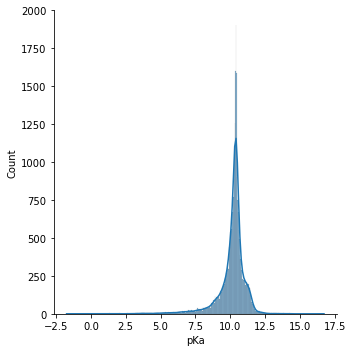

In [12]:
analysis.plot_graph(plot_type = 'histogram', 
                    feature = 'pKa', 
                    uniprot_entry = False, # can also speficy a uniprot code and a resid ID
                    resid = False)

A method to get unusual lysine data using ranges of the feature defined by the user, the output will be a dataframe

In [13]:
analysis.get_extreme_values(feature = 'pKa', lower = 1, upper = 14)

,Uniprot Entry,PDB Code,Method,Resolution,Chain,Resid,pKa,sasa
2462,P72508,result/curated/2UUM-alt1B,X-ray,3.00,D,62,14.94,21.336945
5217,P0A3X7,result/curated/4GYD-alt-1,X-ray,1.80,D,86,14.24,21.735338
5342,Q5N3P4,result/curated/4ROP-alt1B,X-ray,2.05,A,390,16.62,7.644837
5359,Q5N3P4,result/curated/4ROP-alt1A,X-ray,2.05,A,390,15.82,4.343415
5376,Q5N3P4,result/curated/5J04-alt-1,X-ray,2.30,A,390,16.11,8.005465
5393,Q5N3P4,result/curated/5J04-alt-1,X-ray,2.30,B,390,16.74,7.215060
8199,Q93SW9,result/curated/1TU2-alt-6,NMR,-,B,24,14.29,40.244522
8217,Q93SW9,result/curated/1TU2-alt-5,NMR,-,B,24,14.16,36.228846
8226,Q93SW9,result/curated/1TU2-alt-4,NMR,-,B,24,14.21,37.989971
8235,Q93SW9,result/curated/1TU2-alt-1,NMR,-,B,24,14.12,41.848469


A method to remove a sub dataframe from the main dataframe (a convenient way to remove outliers or suspicious data)

In [14]:
df_to_remove = analysis.get_extreme_values(feature = 'pKa', lower = 1, upper = 14)
analysis.remove_df(df_to_remove)

Original length: 28549
Current length: 28532
Num of rows removed: 17


Anther method to aggregate data---for each lysine, only one measurement of pKa & sasa will be included in the df_concise. The criterion of selecting the measurement can either be `average` or `south_east`(the point with relatively lower pKa and higher sasa, the tradeoff of the two features can be controlled by a parameter `weight`, the default value of which is 0.5).

In [15]:
analysis.concise(analysis.df, method = 'average')
#analysis.concise(analysis.df, method = 'south_east', weight = 0.5)
print(len(analysis.df_concise))

3733


An important method to scrape all the GO Terms for each uniprot code from the Uniprot Database, the data will then be stored in a dictionary inside Analysis class

In [16]:
analysis.GO_Get_Data()

In [17]:
analysis.GO_Search_Term(analysis.df, code = '0042803', name = '') # list all the uniprot codes that have a particular GO Term

,Uniprot Entry,PDB Code,Method,Resolution,Chain,Resid,pKa,sasa
0,P73832,result/curated/3EN0-alt1A,X-ray,1.50,A,18,10.11,21.583658
1,P73832,result/curated/3EN0-alt1A,X-ray,1.50,A,66,10.55,63.038871
2,P73832,result/curated/3EN0-alt1A,X-ray,1.50,A,69,10.40,44.281468
3,P73832,result/curated/3EN0-alt1A,X-ray,1.50,A,214,9.88,41.648028
4,P73832,result/curated/3EN0-alt1A,X-ray,1.50,A,263,10.11,47.749819
5,P73832,result/curated/3EN0-alt1A,X-ray,1.50,B,18,9.91,23.292390
6,P73832,result/curated/3EN0-alt1A,X-ray,1.50,B,66,10.64,50.954080
7,P73832,result/curated/3EN0-alt1A,X-ray,1.50,B,69,10.38,47.464098
8,P73832,result/curated/3EN0-alt1A,X-ray,1.50,B,214,10.24,58.123129
9,P73832,result/curated/3EN0-alt1A,X-ray,1.50,B,263,10.17,47.795209


In [18]:
analysis.GO_Search_Protein('P73832') # list all the GO Terms for a particular uniprot code

['protein homodimerization activity',
 'serine-type peptidase activity',
 'cellular macromolecule metabolic process']

## 4. Interactive Plots  <a class="anchor" id="plot"></a>

Once we have scraped all the GO Terms, we pass the `analysis` object to a new class `CoolPlots`

In [19]:
cp = CoolPlots(analysis, outdir = outdir)

In [20]:
"""checking for enrichment within a range"""
pka_range = [1.0, 8.8]
sasa_range = [0.0, 100.0]
df = cp.enrichment_analysis(pka_range, sasa_range)
display(df)

,GO ID,GO Term,raw p value,FDR,num in the region,num in the bkgd
0,0042802,identical protein binding,0.001668,0.080062,10/95,13/277
1,0018298,protein-chromophore linkage,0.010156,0.243744,22/95,43/277
2,0031969,chloroplast membrane,0.048849,0.781585,5/95,7/277
3,0050661,NADP binding,0.107471,0.889135,4/95,6/277
4,0015979,photosynthesis,0.108618,0.889135,43/95,110/277
5,0030089,phycobilisome,0.111142,0.889135,18/95,41/277
6,0031470,carboxysome,0.136546,0.936315,10/95,21/277
7,0003677,DNA binding,0.185634,0.990051,4/95,7/277
8,0051539,"4 iron, 4 sulfur cluster binding",0.185634,0.990051,4/95,7/277
9,0015977,carbon fixation,0.209082,1.000000,9/95,20/277


`advanced_plot` can be used in the following ways:

* without selecting any region, one can examine a GO Term shown in the dropdown lists and then click one of the red points (these are the average or the south_east measurement of the lysines that come from the proteins that have the GO Term). Finally, click a green point (an actual measurement of a lysine based on a particular PDB file) to see the 3D structure.
* one can also first select a region using the slides of pka and sasa. Note this operation will automatically initiate enrichment analysis. A bar chart will be produced based on the results of enrichment analysis. Finally, one can carry on the same process discussed above.
* If a region is selected, the export button can save the data (including GO Terms) within the region to a csv file and store it in the outdir defined by the user
* If a region is selected, the reset button can clear the region and the results of enrichment analysis
* If a 3D visualisation is displayed, the clear button can clear it.

In [22]:
cp.advanced_plot(export_path = 'Regional_Data.csv')